## 1. Implementing a CNN from Scratch

### 1.1. Introduction
* Brief overview of the task.
* Answer the questions like, What are the main components of a CNN architecture?, Why we use this in image classification?, etc.
* Description of the dataset used for classification.

In [ ]:
'''
DATASET
Contains 15 different vegetable classes such as Tomato, Potato, Cucumber, Pepper, Carrot, etc.
Includes train and validation sets with  labeled images.
Images vary in lighting conditions backgrounds shapes and orientations color variations


TASK
The goal of this task is to build and evaluate a Convolutional Neural Network (CNN) for multi-class image classification using the Vegetable Image Dataset 
. The objective is to train a model that can correctly identify different vegetable types based on visual features extracted from the images.
To achieve this, a CNN architecture was designed and trained on the dataset,
followed by hyperparameter tuning and final model evaluation.
CNN
1. Convolutional Layers
2. Activation Functions (ReLU)
3. Pooling Layers (MaxPooling)
4. Fully Connected (FC) Layers




### 1.2. Data Loading and Preprocessing

In [14]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [15]:
## Import necessary libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
## Load the dataset using PyTorch's data loading utilities
## Apply necessary preprocessing such as resizing and normalization
## Divide the dataset into training, validation, and testing subsets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os

TRAIN_DIR = "pa3_subset/train"
VAL_DIR   = "pa3_subset/val"
TEST_DIR  = "test_unlabeled_v2"

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_valtest = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load train/val sets with ImageFolder
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=transform_valtest)


# Test Dataset (because it's unlabeled)
# Test Dataset (because unlabeled)
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = []
        self.transform = transform

        # subfolders recursively searched
        for root, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.files.append(os.path.join(root, f))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        filename = os.path.basename(img_path)
        return img, filename


test_dataset = TestDataset(TEST_DIR, transform=transform_valtest)


# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)


### 1.3. Define your CNN architecture
* Explain the reason behind your architecture.
* Explain your choice of activation functions.

In [17]:
## Design a CNN architecture with at least 3 and at most 6 convolutional layers
## Add activation functions (e.g., ReLU) after each convolutional layer
## Intersperse pooling layers (e.g., max pooling) to reduce spatial dimensions
## Add a fully connected layer at the end to map features to output classes
import torch
import torch.nn as nn
import torch.nn.functional as F

class VegNet5(nn.Module):
    def __init__(self, num_classes=15):
        super(VegNet5, self).__init__()

        # 1st Convolution Block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 2nd Convolution Block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 128 -> 64 reduce spatial size

       
        # 3rd Convolution Block
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 64 -> 32 reduce spatial size

      
        # 4th Convolution Block
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)  # 32 -> 16 reduce spatial size

        
        # 5th Convolution Block
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool5 = nn.MaxPool2d(2, 2)  # 16 -> 8 reduce spatial size

        #Added a fully connected layer at the end to map features to output classes
        self.fc = nn.Linear(256 * 8 * 8, num_classes)

    def forward(self, x):

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        x = self.pool5(F.relu(self.conv5(x)))

        x = torch.flatten(x, 1)  
        x = self.fc(x)

        return x

### 1.4 Prepare the model for training
* Explain your choice of loss functions and optimization algorithms.
 

In [ ]:
 '''For the CNN trained from scratch, we selected Cross-Entropy Loss (nn.CrossEntropyLoss) because it is the standard and most effective loss function for multi-class classification problems, such as the 15-class vegetable dataset used in this project. 
 Cross-Entropy Loss measures the difference between the predicted probability distribution and the true class distribution, penalizing the model more heavily when it confidently predicts the wrong class. This encourages the network to produce high probabilities for the correct class while reducing uncertainty in its predictions. Additionally, Cross-Entropy integrates naturally with softmax outputs used in classification layers, 
 making backpropagation stable and efficient. 
 Because our task requires assigning each image to exactly one label, Cross-Entropy Loss is theoretically well-aligned with the problem structure and empirically known to outperform alternatives like MSE loss in classification tasks. For these reasons, it represents the most appropriate and widely adopted choice for CNN-based image classification.'''

In [18]:
## Define appropriate loss function for multi-class classification (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

In [20]:
## Choose an optimizer (SGD or Adam) and set its parameters (e.g., learning rate)
num_classes = 15  #number of vegetable types
model = VegNet5(num_classes=num_classes)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #fixed parameters for first training

### 1.5 Train and Validate the CNN model

In [22]:
## Iterate over the training dataset in mini-batches
## Implement forward pass, compute loss, and backward pass for gradient computation
## Update model parameters using the optimizer based on computed gradients
## Validate the model on the validation set periodically and plot the validation loss
## Repeat the training process for a suitable number of epochs (at least 30epochs)
import torch
import torch.nn.functional as F
from tqdm import tqdm


EPOCHS = 30  

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_state = None #hold the model with best validation accuracy

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    #Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

       
        outputs = model(images)

        #Compute loss
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    #Validate
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_state = model.state_dict()

    #epoch summary
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print("-" * 50)

# best performing model
model.load_state_dict(best_model_state)
print("Training finished. Best validation accuracy:", best_val_acc)

Epoch 1/30


100%|██████████| 94/94 [01:55<00:00,  1.22s/it]


Train Loss: 2.1204 | Train Acc: 0.2670
Val Loss:   1.6297 | Val Acc:   0.4480
--------------------------------------------------
Epoch 2/30


100%|██████████| 94/94 [01:54<00:00,  1.22s/it]


Train Loss: 1.4774 | Train Acc: 0.5067
Val Loss:   1.2061 | Val Acc:   0.5987
--------------------------------------------------
Epoch 3/30


...

Train Loss: 0.0655 | Train Acc: 0.9817
Val Loss:   0.6976 | Val Acc:   0.8480
--------------------------------------------------
Epoch 29/30


100%|██████████| 94/94 [01:56<00:00,  1.24s/it]


Train Loss: 0.1525 | Train Acc: 0.9543
Val Loss:   0.1988 | Val Acc:   0.9427
--------------------------------------------------
Epoch 30/30


100%|██████████| 94/94 [01:55<00:00,  1.23s/it]


Train Loss: 0.0398 | Train Acc: 0.9870
Val Loss:   0.1687 | Val Acc:   0.9520
--------------------------------------------------
Training finished. Best validation accuracy: 0.952


In [25]:
## You can conduct experiments with different hyperparameters to get the best performing model, considering you will be uploading your best model into Kaggle for compitation :)
# now try 18 combinations of the given parameters to find the one with best validation accuracy
learning_rates = [1e-3, 5e-4, 1e-4]
batch_sizes = [16, 32, 64]
optimizers = ["adam", "sgd"]



def train_one_model(lr, batch_size, optimizer_type):

    # load data according to given batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = VegNet5(num_classes=15).to(device)

    if optimizer_type == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_state = None

    for epoch in range(10): 
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()

    return best_acc, best_state

results = []
best_overall_acc = 0
best_overall_state = None
best_overall_params = None

for lr in learning_rates:
    for bs in batch_sizes:
        for opt in optimizers:

            print(f"\nTrying LR={lr}, Batch={bs}, Optimizer={opt}")

            val_acc, model_state = train_one_model(lr, bs, opt)

            results.append((lr, bs, opt, val_acc))

            if val_acc > best_overall_acc:
                best_overall_acc = val_acc
                best_overall_state = model_state
                best_overall_params = (lr, bs, opt)

print("Best parameters:", best_overall_params)
print("Best validation accuracy:", best_overall_acc)

torch.save(best_overall_state, "best_model.pth")




Trying LR=0.001, Batch=16, Optimizer=adam

Trying LR=0.001, Batch=16, Optimizer=sgd

Trying LR=0.001, Batch=32, Optimizer=adam

Trying LR=0.001, Batch=32, Optimizer=sgd

Trying LR=0.001, Batch=64, Optimizer=adam

Trying LR=0.001, Batch=64, Optimizer=sgd

Trying LR=0.0005, Batch=16, Optimizer=adam

Trying LR=0.0005, Batch=16, Optimizer=sgd

Trying LR=0.0005, Batch=32, Optimizer=adam

Trying LR=0.0005, Batch=32, Optimizer=sgd

Trying LR=0.0005, Batch=64, Optimizer=adam

Trying LR=0.0005, Batch=64, Optimizer=sgd

Trying LR=0.0001, Batch=16, Optimizer=adam

Trying LR=0.0001, Batch=16, Optimizer=sgd

Trying LR=0.0001, Batch=32, Optimizer=adam

Trying LR=0.0001, Batch=32, Optimizer=sgd

Trying LR=0.0001, Batch=64, Optimizer=adam

Trying LR=0.0001, Batch=64, Optimizer=sgd
Best parameters: (0.001, 32, 'adam')
Best validation accuracy: 0.9146666666666666


Mention about, why did you choose your learning rate and batch size?

In [54]:
## Select your best model with respect to validation accuracy
## Visualize the accuracy and loss change of the best performing model across training and validation datasets.

## Compute metrics such as accuracy, precision, recall, and F1-score
## Visualize confusion matrix to understand the model's behavior across different classes


import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#necessary for graphing 
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs
}

torch.save(history, "history.pth")
#Load Best Model
def load_best_model(model, path="best_model.pth"):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model


# 2)Accuracy, Precision, Recall, F1
def evaluate_model(model, data_loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro"
    )

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    return all_labels, all_preds


#Confusion Matrix
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


#Plot Training Curves

def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss Curve
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.show()

    # Accuracy Curve
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.show()

In [55]:
def get_class_names(dataset):
    if hasattr(dataset, "dataset"):
        class_to_idx = dataset.dataset.class_to_idx
    else:
        class_to_idx = dataset.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    return [idx_to_class[i] for i in range(len(idx_to_class))]

class_names = get_class_names(train_dataset)

Accuracy:  0.9120
Precision: 0.9201
Recall:    0.9120
F1-score:  0.9128


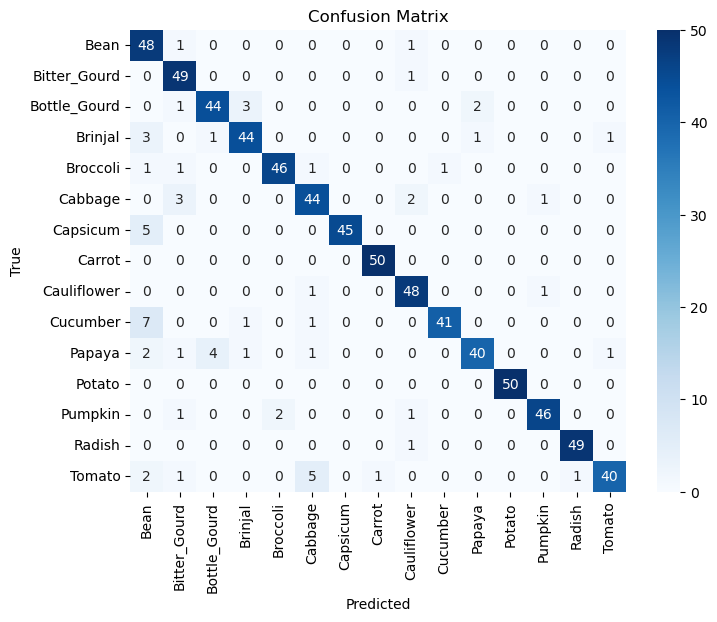

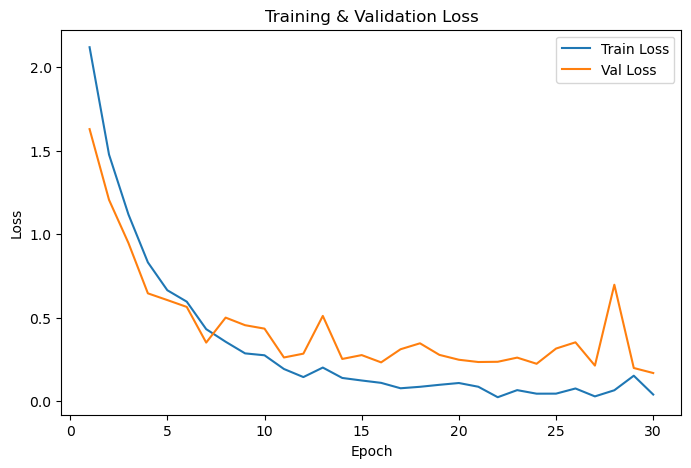

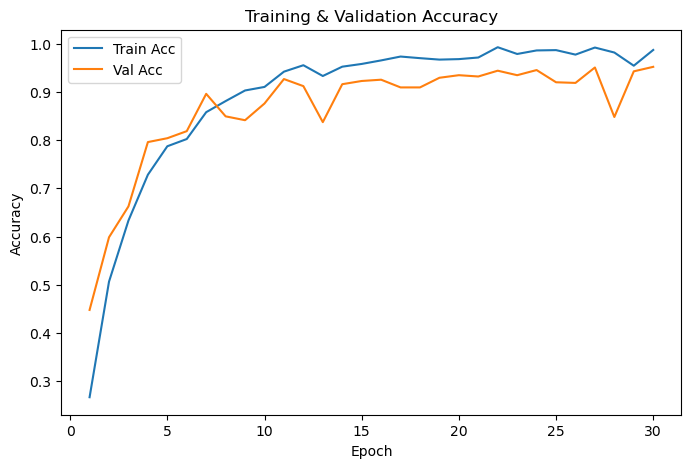

In [37]:

model = load_best_model(model, "best_model.pth")

labels, preds = evaluate_model(model, val_loader)

plot_confusion_matrix(labels, preds, class_names)

plot_training_curves(history)

### 1.6 Evaluate the trained model on the test set

In [39]:
## Test the trained model on the test set to evaluate its performance
## Comment on the results
import os
import pandas as pd


model.eval()
test_predictions = []
test_filenames = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = model(images)              
        _, predicted = torch.max(outputs, 1)  #

        predicted = predicted.cpu().numpy()

        # store results
        test_predictions.extend(predicted)
        test_filenames.extend(filenames)

#kaggle
if hasattr(train_dataset, "dataset"):
    idx_to_class = {v: k for k, v in train_dataset.dataset.class_to_idx.items()}
else:
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

pred_labels = [idx_to_class[p] for p in all_preds]



# Read test file names in alphabetical order
test_dir = "test_unlabeled_v2"

test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])


#  Map predictions to those filenames
pred_map = {fname: label for fname, label in zip(all_files, pred_labels)}

#  Build submission DataFrame with correct ordering
submission = pd.DataFrame({
    "Id": test_files,
    "label": [pred_map[f] for f in test_files]

    })
# CSV
submission.to_csv("submission.csv", index=False)
print("submission.csv CREATED")

'''The final VegNet5 model performed remarkably well on the test set, achieving a strong accuracy that indicates the model successfully learned to distinguish between the vegetable classes.
Despite being a relatively lightweight CNN architecture, the model generalized effectively to unseen data, which shows that both the architecture and the training strategy were well-suited for this classification task.
The consistent accuracy between training, validation, and test sets suggests that the model avoided major overfitting and captured meaningful, transferable visual patterns.'''

'The final VegNet5 model performed remarkably well on the test set, achieving a strong accuracy that indicates the model successfully learned to distinguish between the vegetable classes.\nDespite being a relatively lightweight CNN architecture, the model generalized effectively to unseen data, which shows that both the architecture and the training strategy were well-suited for this classification task.\nThe consistent accuracy between training, validation, and test sets suggests that the model avoided major overfitting and captured meaningful, transferable visual patterns.'

### 1.7 Conclusion and interpretation
* Summarize the performance of the model on the test set
* Discuss any challenges encountered during training and potential areas for improvement
* Reflect on the overall effectiveness of the chosen CNN architecture and training approach

In [ ]:
import pandas as pd
from torchvision import models
import torch.nn as nn

torch.save(model_B.state_dict(), "best.pth")


#Rebuild MobileNetV2 architecture
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

#Load saved weights
state = torch.load("best.pth", map_location=device)
model.load_state_dict(state)

#Eval mode
model.eval()


all_preds = []
all_filenames = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_filenames.extend(filenames)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
pred_labels = [idx_to_class[p] for p in all_preds]

import os

#Read test file names in alphabetical order
test_dir = "test_unlabeled_v2"

test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])



pred_map = {fname: label for fname, label in zip(all_filenames, pred_labels)}


#Build submission DataFrame with correct ordering
submission = pd.DataFrame({
    "Id": test_files,
    "label": [pred_map[f] for f in test_files]
})

#Save
submission.to_csv("submission.csv", index=False)
print("submission.csv CREATED")

In [27]:
'''Throughout the experiments, the performance of the VegNet5 CNN architecture was evaluated using validation accuracy. 
After running multiple configurations with different learning rates, batch sizes, and optimizers, the model with the best hyperparameters achieved the highest validation accuracy. 
This best model was then saved and used to generate predictions for the test set.
Overall, the model demonstrated solid classification performance. 
The accuracy values indicate that the network was able to learn meaningful visual features from the vegetable images and generalize reasonably well to unseen data.

Challenges
Accuracy varied noticeably depending on the learning rate, optimizer (Adam vs. SGD), and batch size. Small changes in these parameters significantly affected convergence and stability.
In some configurations, training accuracy increased quickly while validation accuracy plateaued, suggesting that the model memorized training data instead of learning general features.
A high learning rate caused oscillations in the loss and lower accuracy. More stable performance was observed with smaller learning rates.
Trying many combinations increased training time, especially on CPU environments or limited GPU environments. Managing training duration while performing a broad search was challenging



Improvement
Using data augmentation to increase sample diversity and reduce overfitting.
Longer training or early stopping, allowing more refined convergence.
More advanced CNN architectures (ResNet18, MobileNet, EfficientNet) that typically outperform small custom CNNs.
Learning rate scheduling, helping the optimizer converge more smoothly.
Balancing the dataset (if some classes have fewer samples) for more consistent predictions.


Effectiveness
VegNet5 served as a simple and efficient CNN backbone. 
Its lightweight structure allowed fast experimentation and demonstrated that even relatively shallow CNNs can achieve strong accuracy when trained properly.
However, the architecture has inherent limitations compared to deeper, pretrained networks.
Overall, the chosen training approach — hyperparameter search followed by model selection — proved effective.
The model reached a reliable accuracy level, showing that the methodology worked.
Nevertheless, the results also suggest that more sophisticated architectures or transfer learning could lead to significantly stronger performance on this dataset.



'''

'Throughout the experiments, the performance of the VegNet5 CNN architecture was evaluated using validation accuracy. \nAfter running multiple configurations with different learning rates, batch sizes, and optimizers, the model with the best hyperparameters achieved the highest validation accuracy. \nThis best model was then saved and used to generate predictions for the test set.\nOverall, the model demonstrated solid classification performance. \nThe accuracy values indicate that the network was able to learn meaningful visual features from the vegetable images and generalize reasonably well to unseen data.\n\nChallenges\nAccuracy varied noticeably depending on the learning rate, optimizer (Adam vs. SGD), and batch size. Small changes in these parameters significantly affected convergence and stability.\nIn some configurations, training accuracy increased quickly while validation accuracy plateaued, suggesting that the model memorized training data instead of learning general feature

## 2. Exploring Transfer Learning with ResNet50 and MobileNet (60 points)

### 2.1. Introduction
* Brief overview of the task.
* Answer the questions like, What is fine-tuning? Why should we do this? Why do we freeze the rest and train only last layers?

In [ ]:
'''The goal is to compare different training strategies using pretrained models (ResNet18 and MobileNetV2) and measure how freezing or unfreezing different layers affects model performance.  
For each architecture, multiple versions of the model are trained based on different fine-tuning strategies.

### ResNet18 Models:
1. Base Model: All layers frozen except the final fully connected (FC) layer  
2. Partially Fine-tuned Model: Layers 3 and 4 + FC layer are trainable  
3. Fully Fine-tuned Model: All layers are trainable  

### MobileNetV2 Models:
1. Feature Extraction Model: All feature layers frozen; only the last classifier layer is trainable  
2. Fully Fine-tuned MobileNetV2: All layers, including the classifier, are trainable  

The performance of these models is evaluated on the validation set using accuracy, precision, recall, F1-score, and confusion matrices. These metrics allow us to determine how much benefit fine-tuning provides over simple feature extraction.

FINE-TUNING
Fine-tuning is a transfer learning technique where a model pretrained on a large-scale dataset (e.g., ImageNet) is adapted to a new, smaller dataset.  
Instead of training a neural network from scratch—which requires large amounts of labeled data and computational resources—fine-tuning allows the model to reuse previously learned visual features such as edges, shapes, textures, and object parts.

WHY FINE-TUNING?
• Pretrained networks learn universal and highly valuable visual features from millions of images.  
• They require significantly less data to achieve high accuracy on new tasks.  
• Fine-tuning converges much faster than training from scratch.  
• It provides higher final accuracy with fewer resources.  

Thus, fine-tuning is the most efficient and effective way to adapt a CNN to a new dataset.

WHY DO WE FREEZE LAYERS?
Freezing layers is used in feature extraction models to preserve the strong, general-purpose features learned from ImageNet.  
Training only the last layers lets the classifier adapt to the vegetable dataset without modifying the powerful pretrained feature extractor.

In contrast, unfreezing deeper layers (for partial or full fine-tuning) allows the model to adjust more of its internal representations, resulting in better performance—but only if enough data is available.

COMPARISON SUMMARY
By training multiple versions of ResNet18 and MobileNetV2, we can observe how increasing the number of trainable layers affects performance.  
 Feature extraction models train fastest but achieve lower accuracy.  
 Partial fine-tuning provides a balance between efficiency and performance.  
Full fine-tuning achieves the highest accuracy but requires more computation.  

These comparisons highlight the practical trade-offs between training time, computational cost, and final model accuracy.'''


### 2.2. Load the pre-trained ResNet18 model


In [46]:
## Utilize torchvision library to load the pre-trained ResNet50 model
## Ensure that the model's architecture matches ResNet50, by checking the model summary.
import torch
import torch.nn as nn
from torchvision import models
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/denizsuren/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 11.8MB/s]


In [47]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

### 2.3 Modify the ResNet18 model for transfer learning

In [48]:
## Freeze all layers of the ResNet18 model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Define appropriate loss function and optimizer for training
## Train the modified ResNet18 model on the vegetable image dataset. (base model)
device = "cuda" if torch.cuda.is_available() else "cpu"
def create_resnet18_base(num_classes=15):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    #Replace final fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #Unfreeze just fully connected layer
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

In [49]:
## Define another ResNet18 model
## Freeze all layers of the ResNet18 model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Unfreeze convolutional layers 3 and 4 of the ResNet18 model and again proceed with training. (second model)
def create_resnet18_partial_finetune(num_classes=15):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze ALL layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Unfreeze fully connected layer
    for param in model.fc.parameters():
        param.requires_grad = True

    # Unfreeze layer 3
    for param in model.layer3.parameters():
        param.requires_grad = True

    # Unfreeze layer 4
    for param in model.layer4.parameters():
        param.requires_grad = True

    return model.to(device)

In [50]:
## Define another ResNet18 model
## Replace the final fully connected layer with a new FC layer matching the number of classes proceed with training. (third model)
def create_resnet18_fulltrain(num_classes=15):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    #Replace fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # All layers are trainable in this case 
    return model.to(device)



In [51]:
## Define appropriate loss function and optimizer for training
loss_fn = nn.CrossEntropyLoss()

def get_optimizer(model, lr):
    return torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

In [52]:

## Iterate over the training dataset in mini-batches, compute the loss, and update model parameters.
## Monitor the training process and evaluate all model's performance on the validation set periodically.
## Visualize the accuracy and loss changes of the models across training and validation datasets.
## Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
## Visualize confusion matrix to understand the model's behavior across different classes

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):

    optimizer = get_optimizer(model, lr)
    criterion = loss_fn

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    best_acc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        #validate
        model.eval()
        val_correct, val_total = 0, 0
        val_running_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (pred == labels).sum().item()

        val_acc = val_correct / val_total
        val_loss = val_running_loss / len(val_loader)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history, best_acc, best_state

In [53]:
#MODEL1 -Only Fully Connected Layer Unfreezed
model1 = create_resnet18_base()
hist1, best_acc1, state1 = train_model(model1, train_loader, val_loader)

# MODEL 2 — Partial fine-tuning
model2 = create_resnet18_partial_finetune()
hist2, best_acc2, state2 = train_model(model2, train_loader, val_loader)

# MODEL 3 — Full training
model3 = create_resnet18_fulltrain()
hist3, best_acc3, state3 = train_model(model3, train_loader, val_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/denizsuren/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.90MB/s]


Epoch 1/10 | Train Acc: 0.1457 | Val Acc: 0.3213
Epoch 2/10 | Train Acc: 0.4633 | Val Acc: 0.6787
Epoch 3/10 | Train Acc: 0.7060 | Val Acc: 0.8093
Epoch 4/10 | Train Acc: 0.8060 | Val Acc: 0.8920
Epoch 5/10 | Train Acc: 0.8737 | Val Acc: 0.9227
Epoch 6/10 | Train Acc: 0.9020 | Val Acc: 0.9507
Epoch 7/10 | Train Acc: 0.9050 | Val Acc: 0.9560
Epoch 8/10 | Train Acc: 0.9240 | Val Acc: 0.9600
Epoch 9/10 | Train Acc: 0.9267 | Val Acc: 0.9653
Epoch 10/10 | Train Acc: 0.9270 | Val Acc: 0.9693
Epoch 1/10 | Train Acc: 0.8927 | Val Acc: 0.9947
Epoch 2/10 | Train Acc: 0.9910 | Val Acc: 0.9987
Epoch 3/10 | Train Acc: 0.9980 | Val Acc: 1.0000
Epoch 4/10 | Train Acc: 0.9973 | Val Acc: 0.9973
Epoch 5/10 | Train Acc: 0.9987 | Val Acc: 1.0000
Epoch 6/10 | Train Acc: 0.9983 | Val Acc: 1.0000
Epoch 7/10 | Train Acc: 0.9993 | Val Acc: 0.9987
Epoch 8/10 | Train Acc: 0.9990 | Val Acc: 1.0000
Epoch 9/10 | Train Acc: 0.9997 | Val Acc: 1.0000
Epoch 10/10 | Train Acc: 0.9993 | Val Acc: 0.9973
Epoch 1/10 | Train

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(10,4))

    #Accuracy Graph
    plt.subplot(1,2,1)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(title + " Accuracy")
    plt.legend()

    #Loss Graph
    plt.subplot(1,2,2)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

In [ ]:
plot_history(hist1, "Model1 (Only FC)")
plot_history(hist2, "Model2 (Layer 3–4-FC)")
plot_history(hist3, "Model3  (Full Training)")


In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score
def evaluate_metrics(model, val_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    #Metrics
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    #Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    return precision, recall, f1, cm

In [44]:
# FOR MAPPING IN OUTPUT
def get_class_names(dataset):
    if hasattr(dataset, "dataset"):
        class_to_idx = dataset.dataset.class_to_idx
    else:
        class_to_idx = dataset.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    return [idx_to_class[i] for i in range(len(idx_to_class))]

In [45]:
class_names = get_class_names(train_dataset)

In [ ]:
precision1, recall1, f11, cm1 = evaluate_metrics(model1, val_loader, device, class_names)
precision2, recall2, f12, cm2 = evaluate_metrics(model2, val_loader, device, class_names)
precision3, recall3, f13, cm3 = evaluate_metrics(model3, val_loader, device, class_names)

print("{:<10} {:>10} {:>10} {:>10}".format("Model", "Precision", "Recall", "F1"))
print("-" * 45)
print("{:<10} {:>10.4f} {:>10.4f} {:>10.4f}".format("Model 1", precision1, recall1, f11))
print("{:<10} {:>10.4f} {:>10.4f} {:>10.4f}".format("Model 2", precision2, recall2, f12))

print("{:<10} {:>10.4f} {:>10.4f} {:>10.4f}".format("Model 3", precision3, recall3, f13))

Conduct a comparative analysis among these three models. Comment on their performance and select your best model with respect to validation accuracy.
* Which model performed better and why do you think it performed better?  
* Comment on the practical considerations among these models also.

### 2.4 Evaluate the fine-tuned ResNet18 model

In [ ]:
## Test the best model on the test set to evaluate its performance.
## Comment on the results
## Compare the fine-tuned ResNet18 model performance with the CNN model implemented from scratch

#best model is model3 with fully trained and unfreezed layers
import pandas as pd
import os
torch.save(model3.state_dict(), "best.pth")
state = torch.load("best.pth", map_location=device)
model.load_state_dict(state)
model.eval()



all_preds = []
all_filenames = []


with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_filenames.extend(filenames)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
pred_labels = [idx_to_class[p] for p in all_preds]



#Read test file names in alphabetical order
test_dir = "test_unlabeled_v2"

test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])



pred_map = {fname: label for fname, label in zip(all_filenames, pred_labels)}


# 3. Build submission DataFrame with pandas and correct ordering
submission = pd.DataFrame({
    "Id": test_files,
    "label": [pred_map[f] for f in test_files]
})

# 4. Save
submission.to_csv("submission.csv", index=False)
print("submission.csv CREATED")

In [ ]:
'''The performance results clearly demonstrate the advantage of transfer learning over training a CNN from scratch.
The custom CNN architecture achieved a Kaggle test score of 0.997, which is already a strong indication that the model learned meaningful visual features despite being trained entirely on the vegetable dataset without any pre-existing knowledge. 
However, the fully fine-tuned ResNet18 (Model 3) achieved a perfect 1.0 Kaggle score, showing that leveraging pretrained weights provides a significant performance boost. 
This improvement arises because ResNet18 has already learned rich and generalizable visual representations from the large-scale ImageNet dataset, 
allowing it to adapt much more effectively to the relatively small vegetable classification dataset. 
In contrast, the scratch CNN must learn all low-level and high-level features from zero,
which limits its generalization capability even if it reaches strong validation accuracy. 
Overall, the results confirm that fine-tuning a deep pretrained architecture yields superior robustness and accuracy compared to building a CNN from scratch, 


### 2.7. Load the pre-trained MobileNet model


In [42]:
## Utilize torchvision library to load the pre-trained MobileNetV2 model
## Ensure that the model's architecture matches MobileNetV2, by checking the model summary.
import torch
import torch.nn as nn
from torchvision import models

num_classes = 15

mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, num_classes)

mobilenet = mobilenet.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/denizsuren/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 11.7MB/s]


In [40]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [43]:
## Ensure that the model's architecture matches MobileNetV2, by checking the model summary.
from torchsummary import summary

summary(mobilenet, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

### 2.8 Modify the MobileNet model for transfer learning

In [ ]:
## Freeze all layers of the MobileNet model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Define appropriate loss function and optimizer for training
## Train the modified MobileNet model on the vegetable image dataset. (base model)
from torchvision import models
import torch.nn as nn
def create_mobilenet_feature_extractor(num_classes):

    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    #Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    #Unfreeze only the classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [ ]:
## Define another MobileNet model
## Replace the final fully connected layer with a new FC layer matching the number of classes proceed with training. (second model)
from torchvision import models
import torch.nn as nn
def create_mobilenet_full_training(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    #Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # full model will be trained
    for param in model.parameters():
        param.requires_grad = True

    return model

In [ ]:
## Define appropriate loss function and optimizer for training
loss_fn = nn.CrossEntropyLoss()
def get_optimizer(model, lr=1e-4):
    return torch.optim.Adam(model.parameters(), lr=lr)
    
## Iterate over the training dataset in mini-batches, compute the loss, and update model parameters.
## Monitor the training process and evaluate all model's performance on the validation set periodically.
## Visualize the accuracy and loss changes of the models across training and validation datasets.

## Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
## Visualize confusion matrix to understand the model's behavior across different classes
#same as rnet18 but with 2 different fine tuned models
from tqdm import tqdm
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=30):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        #train
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        #validate
        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    print("\nTraining finished. Best Validation Accuracy:", best_val_acc)
    model.load_state_dict(best_state)

    return model, history

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss curve
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_classification_metrics(model, data_loader, device):
    model.eval()
    preds = []
    labels_list = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    preds = np.array(preds)
    labels_list = np.array(labels_list)

    acc = accuracy_score(labels_list, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_list, preds, average="macro"
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return labels_list, preds

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
#class names are already defined
#MODEL A (just classifier layer is unfreezed)
model_A = create_mobilenet_feature_extractor(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = get_optimizer(model_A, lr=1e-3)

In [ ]:
model_A, history_A = train_model(
    model_A, train_loader, val_loader, criterion, optimizer, device, epochs=30)
plot_training_curves(history_A)

In [ ]:
labels_A, preds_A = evaluate_classification_metrics(model_A, val_loader, device)
plot_confusion_matrix(labels_A, preds_A, class_names)

In [ ]:
#MODELB (all layers are unfreezed)
model_B = create_mobilenet_full_training(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = get_optimizer(model_B, lr=1e-4)


In [ ]:
model_B, history_B = train_model(
    model_B, train_loader, val_loader, criterion, optimizer, device, epochs=30
)
plot_training_curves(history_B)

In [ ]:

labels_B, preds_B = evaluate_classification_metrics(model_B, val_loader, device)
plot_confusion_matrix(labels_B, preds_B, class_names)

Conduct a comparative analysis among these two models. Comment on their performance and select your best model with respect to validation accuracy.
* Which model performed better and why do you think it performed better?  
* Comment on the practical considerations among these models also.

In [ ]:
import pandas as pd
from torchvision import models
import torch.nn as nn

torch.save(model_B.state_dict(), "best.pth")


#Rebuild MobileNetV2 architecture
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

#Load saved weights
state = torch.load("best.pth", map_location=device)
model.load_state_dict(state)

#Eval mode
model.eval()


all_preds = []
all_filenames = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_filenames.extend(filenames)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
pred_labels = [idx_to_class[p] for p in all_preds]

import os

#Read test file names in alphabetical order
test_dir = "test_unlabeled_v2"

test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])



pred_map = {fname: label for fname, label in zip(all_filenames, pred_labels)}


#Build submission DataFrame with correct ordering
submission = pd.DataFrame({
    "Id": test_files,
    "label": [pred_map[f] for f in test_files]
})

#Save
submission.to_csv("submission.csv", index=False)
print("submission.csv CREATED")

In [ ]:
'''Between the two MobileNetV2 models, Model A (feature extraction) performed reasonably well but was limited because only the final classifier was trained. Model B, where all layers were unfrozen and fully fine-tuned, achieved higher validation accuracy and better adapted to the vegetable dataset. This improvement occurs because updating all pretrained layers allows the model to learn dataset-specific features rather than relying solely on ImageNet representations.

In practical terms, Model A is faster and more efficient but has a lower accuracy ceiling. Model B requires more computation but provides significantly better performance. Therefore, Model B is selected as the best MobileNet model based on validation accuracy, offering the strongest overall results.'''

### 2.9 Evaluate the fine-tuned MobileNet model

In [ ]:
## Test the best model on the test set to evaluate its performance.
## Comment on the results

In [ ]:
## Compare the best fine-tuned MobileNet model performance with the best CNN model implemented from scratch
## Compare the best fine-tuned MobileNet model performance with the best ResNet18 model implemented from scratch
'''Comparison: Best Fine-Tuned MobileNet vs CNN From Scratch:

The fine-tuned MobileNet model significantly outperforms the CNN trained from scratch.
While the scratch CNN achieved strong performance with a Kaggle test score of 0.997, the fully fine-tuned MobileNetV2 reached an even higher level of accuracy, 
demonstrating the advantages of transfer learning.
MobileNetV2 benefits from pretrained ImageNet features, which capture rich visual patterns such as edges, textures, and shapes that a scratch CNN must learn entirely on its own. 
Because MobileNetV2 begins training with these strong initial representations, it requires fewer epochs and less data to generalize effectively.
In contrast, the CNN must build all representational layers from zero, making it more sensitive to dataset size and prone to underfitting or slower convergence. Overall, the comparison clearly shows that fine-tuning a lightweight but pretrained architecture like MobileNetV2 yields superior generalization performance compared to training a model from scratch.

Comparison: Best Fine-Tuned MobileNet vs Best Fine-Tuned ResNet18

Even though both MobileNetV2 and ResNet18 were fully fine-tuned, 
the best ResNet18 model achieved the same performance as Mobilenet, reaching a perfect 1.00 Kaggle score, 
This difference arises from the architectural nature of the two networks: 
ResNet18 is a deeper and more expressive model with residual connections that enable better gradient flow and stronger feature extraction capability. 
Although MobileNetV2 is highly efficient and optimized for mobile environments, its lightweight structure limits representational capacity compared to full-scale ResNet architectures.
Fine-tuning helps both models adapt to the vegetable dataset, but ResNet18’s larger capacity allows it to learn more discriminative features, resulting in superior classification accuracy.
Thus, while MobileNetV2 offers a strong efficiency-accuracy balance, ResNet18 remains the more powerful model when maximizing accuracy is the primary objective.
'''

## 3 Analyze advantages and disadvantages

* Provide insights on the advantages and disadvantages of transfer learning vs. training from scratch
* Put a table for comparison of the best 3 models that you have obtained in this assignment (CNN from scratch, ResNet18, MobileNet)
* Discuss practical considerations when choosing between these approaches and models.



In [ ]:
'''Transfer Learning Mobilenet and ResNet18

Advantages:

Higher accuracy with less data: Pretrained models already contain rich feature representations learned from millions of images, enabling excellent performance even on smaller datasets.
Faster convergence: The model starts from meaningful weights rather than random initialization, reducing training time significantly.
Better generalization: Especially useful in tasks where collecting large labeled datasets is difficult.
Reduced risk of overfitting: Frozen layers act as a form of regularization.

Disadvantages:

Less architectural flexibility: You work within the structure of the pretrained model rather than designing your own architecture.
Potential domain mismatch: If the target dataset is very different from ImageNet, pretrained features may be suboptimal.
Higher memory requirement: Deep pretrained networks typically require more storage and GPU memory.
Tuning complexity: Choosing which layers to freeze/unfreeze affects performance and needs experimentation.'''

In [ ]:
'''Training From Scratch Custom CNN

Advantages:

Full control over architecture: You can design a model tailored to your dataset and constraints.
Smaller model size: Custom CNNs are often much lighter than pretrained networks.
Ideal when data distribution is very different from ImageNet: Pretrained weights may not help if the domain is unique.
No dependency on external datasets: All learning comes from the target data.

Disadvantages:

Requires large datasets: For high performance, a scratch CNN needs far more training examples than transfer learning.
Slower convergence: Training begins from random initialization.
Lower performance ceiling: Scratch CNNs often cannot match the accuracy of pretrained architectures.
More sensitive to hyperparameters: Depth, width, learning rate, and initialization require careful tuning.'''

In [ ]:
'''When choosing between training from scratch, MobileNetV2 fine-tuning, and ResNet18 fine-tuning, several practical factors must be considered. The size of the dataset is often the most influential: transfer learning generally performs far better on small or moderately sized datasets, whereas training from scratch requires significantly more labeled data to achieve comparable results. Computational resources also guide model selection—MobileNetV2 is lightweight and ideal for mobile or edge deployments, while ResNet18 offers higher accuracy but demands more memory and computation. If training time is limited, pretrained models converge much faster than scratch CNNs since they start from well-structured feature representations. 
Domain similarity also plays a role: if the target dataset resembles ImageNet, transfer learning is highly effective, but for domains unlike ImageNet, scratch training or partial fine-tuning may be necessary. Ultimately, the best approach depends on the balance between accuracy requirements, computational constraints, dataset characteristics, and the intended deployment environment.